
# Step 08 — Integration sensitivity analysis

**Purpose.** The main pipeline does not apply batch correction. This notebook runs
it again *with* Harmony, writes the result to a separate directory, and asks a
single question: **which conclusions in the report would change if that decision
had gone the other way?**

## Why integration was not applied in the first place

Each timepoint is its own pair of 10x runs, so condition and sequencing batch are
completely confounded by design. Correcting on `sample` therefore risks removing
the injury response along with the batch effect. The variance decomposition in
step 04 supported the decision — condition explains roughly nine-fold more
principal component variance than replicate — but that is an argument, not a
demonstration.

## What this notebook is, and is not

This is a **sensitivity analysis**, not a replacement. The uncorrected result
remains primary. Whichever way this comes out is worth reporting:

- **Nothing changes** → the batch-correction decision is vindicated empirically
  rather than merely argued.
- **The rod paralog split appears** → that would locate the failure in batch
  structure rather than in normalisation, which is a substantive finding.

## Requirement

```
uv pip install harmonypy
```

Record it in `requirements.txt` and in the Methods section: installing a package
to enable an analysis is a methodological choice, not a detail.

In [1]:
import sys
from pathlib import Path

# Make the repository root importable regardless of where Jupyter was launched.
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "scripts").exists():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "scripts").exists(), (
    f"Cannot locate the repository root from {Path.cwd()}. "
    "Launch JupyterLab from the repository root."
)
sys.path.insert(0, str(REPO_ROOT))

from scripts import config as cfg
from scripts import io_utils, qc, preprocessing, clustering, annotation, egfp_analysis, plotting

cfg.ensure_directories()
plotting.set_style()
SEED = io_utils.set_seeds()
print(f"Repository root: {REPO_ROOT}")
print(f"Random seed: {SEED}")

Repository root: D:\retina\project1_zebrafish_retina
Random seed: 0


In [2]:
import pandas as pd
from scripts import integration_check as ic

try:
    import harmonypy  # noqa: F401
    print("harmonypy available.")
except ImportError:
    raise ImportError(
        "harmonypy is not installed. Run:  uv pip install harmonypy\n"
        "then restart the kernel and re-run this notebook."
    )

harmonypy available.



## 1. Load both starting points

The preprocessed object is the input to correction; the annotated object supplies
the cell type labels and the uncorrected clustering to compare against.

In [3]:
adata_int = io_utils.load_checkpoint("preprocessed")
annotated = io_utils.load_checkpoint("annotated")

# Carry the uncorrected clustering across so both partitions sit on the same cells.
adata_int.obs[cfg.LEIDEN_KEY] = annotated.obs[cfg.LEIDEN_KEY].reindex(adata_int.obs_names)
adata_int = adata_int[adata_int.obs[cfg.LEIDEN_KEY].notna()].copy()
print(f"{adata_int.n_obs} cells carried into the integration check.")

Loaded 'preprocessed': 15893 cells x 2000 genes
Loaded 'annotated': 15893 cells x 2000 genes
15893 cells carried into the integration check.



## 2. Apply Harmony and re-cluster

Harmony corrects the PCA embedding rather than the expression matrix, so `.raw`
and `layers['lognorm']` are untouched. Any differential expression run afterwards
uses exactly the same values as the uncorrected analysis — only the neighbourhood
structure changes.

In [4]:
adata_int = ic.run_integrated(adata_int, batch_key="sample")

2026-08-31 11:39:40,432 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-08-31 11:39:40,433 - harmonypy - INFO -   Parameters:
2026-08-31 11:39:40,434 - harmonypy - INFO -     max_iter_harmony: 10
2026-08-31 11:39:40,434 - harmonypy - INFO -     max_iter_kmeans: 20
2026-08-31 11:39:40,435 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-08-31 11:39:40,436 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-08-31 11:39:40,437 - harmonypy - INFO -     nclust: 100
2026-08-31 11:39:40,438 - harmonypy - INFO -     block_size: 0.05
2026-08-31 11:39:40,440 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1.]
2026-08-31 11:39:40,441 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2.]
2026-08-31 11:39:40,442 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-08-31 11:39:40,444 - harmonypy - INFO -     verbose: True
2026-08-31 11:39:40,444 - harmonypy - INFO -     random_state: 0
2026-08-31 11:39:40,446 - harmonypy - INFO -   Data: 50 PCs × 15893 cells
2026-0

PCA: 50 components, 27.6% of variance retained.


2026-08-31 11:39:43,042 - harmonypy - INFO - KMeans initialization complete.
2026-08-31 11:39:43,069 - harmonypy - INFO - Iteration 1 of 10
2026-08-31 11:39:45,088 - harmonypy - INFO - Iteration 2 of 10
2026-08-31 11:39:47,149 - harmonypy - INFO - Iteration 3 of 10
2026-08-31 11:39:48,903 - harmonypy - INFO - Iteration 4 of 10
2026-08-31 11:39:50,360 - harmonypy - INFO - Iteration 5 of 10
2026-08-31 11:39:52,390 - harmonypy - INFO - Iteration 6 of 10
2026-08-31 11:39:53,326 - harmonypy - INFO - Iteration 7 of 10
2026-08-31 11:39:54,240 - harmonypy - INFO - Iteration 8 of 10
2026-08-31 11:39:55,143 - harmonypy - INFO - Iteration 9 of 10
2026-08-31 11:39:56,018 - harmonypy - INFO - Iteration 10 of 10
2026-08-31 11:39:56,864 - harmonypy - INFO - Stopped before convergence


Harmony applied on 'sample' (harmonypy returned 15893x50); corrected embedding of shape (15893, 50) in obsm['X_pca_harmony'].


D:\retina\project1_zebrafish_retina\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Leiden on the corrected embedding: 22 clusters -> obs['leiden_int_0.6']



## 3. How much batch structure did the correction actually remove?

This repeats the step 04 variance decomposition on both embeddings. Replicate is
the informative factor, since replicates within a condition differ only
technically. Watch what happens to **condition** as well: if it falls as much as
replicate, the correction is removing biology along with batch.

In [5]:
var_df = ic.batch_variance_before_after(adata_int)
ic.save_int_table(var_df, "batch_variance_before_after.csv")

embedding  harmony  uncorrected
factor                         
condition   0.0041       0.0201
replicate   0.0016       0.0023
sample      0.0060       0.0244
Wrote tables\integration_check\batch_variance_before_after.csv  (6 rows)


WindowsPath('D:/retina/project1_zebrafish_retina/tables/integration_check/batch_variance_before_after.csv')


## 4. Do the two clusterings agree?

The adjusted Rand index compares the two partitions cell by cell. Near 1 means
integration barely changed the structure; a low value means it was substantially
rearranged.

In [6]:
agreement = ic.cluster_agreement(adata_int)
ic.save_int_table(pd.DataFrame([agreement]), "cluster_agreement.csv")

Clusters: 20 uncorrected vs 22 integrated
Adjusted Rand index: 0.6112  (1.0 = identical partition, 0 = no better than chance)
Wrote tables\integration_check\cluster_agreement.csv  (1 rows)


WindowsPath('D:/retina/project1_zebrafish_retina/tables/integration_check/cluster_agreement.csv')

In [7]:
adata_int, purity = ic.transfer_labels(adata_int, annotated)
ic.save_int_table(purity, "integrated_cluster_purity.csv")
display(purity.head(20))

3 integrated cluster(s) below 0.8 purity — these merge populations that were separate before correction:
integrated_cluster  n_cells     majority_cell_type  purity        second_type
                 0     3793                   Rods   0.740 Rods (low quality)
                 7      930              Microglia   0.700         Unresolved
                21       39 Retinal ganglion cells   0.615        Muller glia
Wrote tables\integration_check\integrated_cluster_purity.csv  (22 rows)


,integrated_cluster,n_cells,majority_cell_type,purity,second_type,second_frac
0,0,3793,Rods,0.740,Rods (low quality),0.245
5,5,1806,Cones,0.822,Muller glia,0.089
12,12,1611,Muller glia,0.877,Rods (low quality),0.045
2,2,1484,Rods,0.968,Muller glia,0.012
8,8,1262,Bipolar cells,0.812,Amacrine cells,0.090
15,15,1079,Cones,0.985,Rods,0.006
13,13,944,Amacrine cells,0.875,Retinal ganglion cells,0.068
7,7,930,Microglia,0.700,Unresolved,0.275
6,6,825,RPE,0.985,Rods (low quality),0.006
3,3,612,Horizontal cells,0.964,Muller glia,0.031



### Interpretation

Labels are carried across by barcode rather than re-derived, because the question
here is whether integration changes the *structure*, not whether it changes the
analyst's judgement.

The purity column is the informative one. A cluster at purity 0.95 corresponds
cleanly to one previously annotated type. A cluster at 0.55 has merged two
populations that were previously separate — which is exactly the risk of
correcting on a variable confounded with condition.


## 5. The EGFP time course

Expected to be **identical**. Positivity is a raw transgene count call that does
not depend on the embedding or on clustering. A difference here would indicate a
bug rather than a biological effect, and this cell is partly a check on the
analysis itself.

In [8]:
egfp_df = ic.compare_egfp(adata_int, annotated)
ic.save_int_table(egfp_df, "egfp_timecourse_comparison.csv")

EGFP feature found in var_names as: 'EGFP'
EGFP feature 'EGFP': 481/15893 cells positive (3.03%) at >= 1 raw count(s). Max counts in one cell: 256.
EGFP feature found in var_names as: 'EGFP'
EGFP feature 'EGFP': 481/15893 cells positive (3.03%) at >= 1 raw count(s). Max counts in one cell: 256.

EGFP-positive % per condition:
analysis   integrated  uncorrected  difference
condition                                     
ctrl             0.56         0.56         0.0
3dp              5.39         5.39         0.0
7dp              2.45         2.45         0.0
10dp             2.80         2.80         0.0
Identical, as expected — positivity does not depend on the embedding.
Wrote tables\integration_check\egfp_timecourse_comparison.csv  (8 rows)


WindowsPath('D:/retina/project1_zebrafish_retina/tables/integration_check/egfp_timecourse_comparison.csv')

In [9]:
enrich_df = ic.compare_egfp_enrichment(adata_int, annotated)
ic.save_int_table(enrich_df, "egfp_enrichment_comparison.csv")


EGFP-positive % per cell type:
analysis                integrated  uncorrected  difference
cell_type                                                  
Muller glia                  12.29        11.34        0.95
Pericytes                     4.92         5.88       -0.96
Retinal ganglion cells        2.56         5.15       -2.59
Amacrine cells                2.71         3.77       -1.06
Cones                         3.19         3.18        0.01
Horizontal cells              3.43         2.67        0.76
Oligodendrocytes              1.50         2.33       -0.83
Unresolved                    7.14         2.19        4.95
Bipolar cells                 2.73         1.88        0.85
Microglia                     1.40         1.82       -0.42
Rods (low quality)             NaN         1.13         NaN
Rods                          1.02         1.09       -0.07
Erythrocytes                  0.49         0.50       -0.01
RPE                           0.24         0.24        0.00
Wrote ta

WindowsPath('D:/retina/project1_zebrafish_retina/tables/integration_check/egfp_enrichment_comparison.csv')


### Interpretation

The time course should not move. The **per-cell-type enrichment** can move, because
cells shift between clusters and so each cell type's denominator changes even
though the positivity call does not. If Müller glia remain the top population by a
clear margin, the central claim of the report is robust to the integration
decision.


## 6. The rod paralog test

This is the one comparison where integration could plausibly change a conclusion.
In the uncorrected analysis, one of three paralog pairs split, and discordantly —
so the published immature/mature rod distinction was not reproduced.

If integration recovers the split, the failure was in batch structure. If it does
not, normalisation and the stress axis remain the leading explanations.

In [10]:
paralogs, verdict = ic.compare_rod_paralogs(adata_int, annotated)
ic.save_int_table(paralogs, "rod_paralogs_integrated.csv")
display(paralogs)


Rod subset from the integrated object: 5277 cells (Rods, Rods (low quality))
Sub-analysis rebuilt from .raw: 22813 genes available (vs 2000 in the HVG-subset object).


C:\Users\Lenovo\AppData\Roaming\uv\python\cpython-3.11-windows-x86_64-none\Lib\functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Subset re-clustered at resolution 0.3: 4 subclusters, 5277 cells.

Paralog expression across integrated rod subclusters:
            n_cells    rho   rhol  pde6ga  pde6gb  guca1a  guca1b
subcluster                                                       
0               550  6.938  1.540   4.377   5.387   2.206   1.621
1              1760  6.208  1.695   4.314   4.732   1.609   1.878
2              2944  7.655  1.239   3.902   5.712   2.934   0.980
3                23  5.608  1.447   3.720   4.032   1.728   1.692

Inversion test on the integrated data:
  rho/rhol: rho > rhol in every subcluster — no inversion
  pde6ga/pde6gb: pde6gb > pde6ga in every subcluster — no inversion
  guca1a/guca1b: SPLIT across subclusters — inversion present

1 of 3 pairs split. The published result requires all three to split in a coordinated, reciprocal way.
Consistent with the uncorrected analysis: integration does not recover the published rod split.
Wrote tables\integration_check\rod_paralogs_integrated.

,subcluster,n_cells,rho,rhol,pde6ga,pde6gb,guca1a,guca1b
0,0,550,6.938,1.540,4.377,5.387,2.206,1.621
1,1,1760,6.208,1.695,4.314,4.732,1.609,1.878
2,2,2944,7.655,1.239,3.902,5.712,2.934,0.980
3,3,23,5.608,1.447,3.720,4.032,1.728,1.692



## 7. Cell-type proportions

In [11]:
prop_df = ic.compare_proportions(adata_int, annotated)
ic.save_int_table(prop_df, "proportions_comparison.csv")
display(prop_df[prop_df["cell_type"].isin(["Rods", "Muller glia", "Cones", "Microglia"])])


Cell-type proportions (%) per condition, both analyses — see tables/integration_check/proportions_comparison.csv
Wrote tables\integration_check\proportions_comparison.csv  (27 rows)


condition,cell_type,ctrl,3dp,7dp,10dp,analysis
0,Muller glia,8.39,11.32,10.60,13.30,uncorrected
1,Rods,11.89,34.10,26.70,29.16,uncorrected
2,Cones,25.92,16.27,12.77,14.74,uncorrected
7,Microglia,2.23,3.99,4.88,4.68,uncorrected
16,Cones,27.95,17.66,14.68,16.39,integrated
19,Microglia,2.62,7.71,5.77,5.97,integrated
20,Muller glia,7.99,10.31,9.23,11.60,integrated
25,Rods,12.56,38.50,38.18,35.26,integrated



## 8. Figures

Four panels for the report. The variance figure is the one that carries the
argument; the confusion heatmap shows which populations the correction damaged.

Saved int_fig1_umap_before_after -> figures/integration_check/


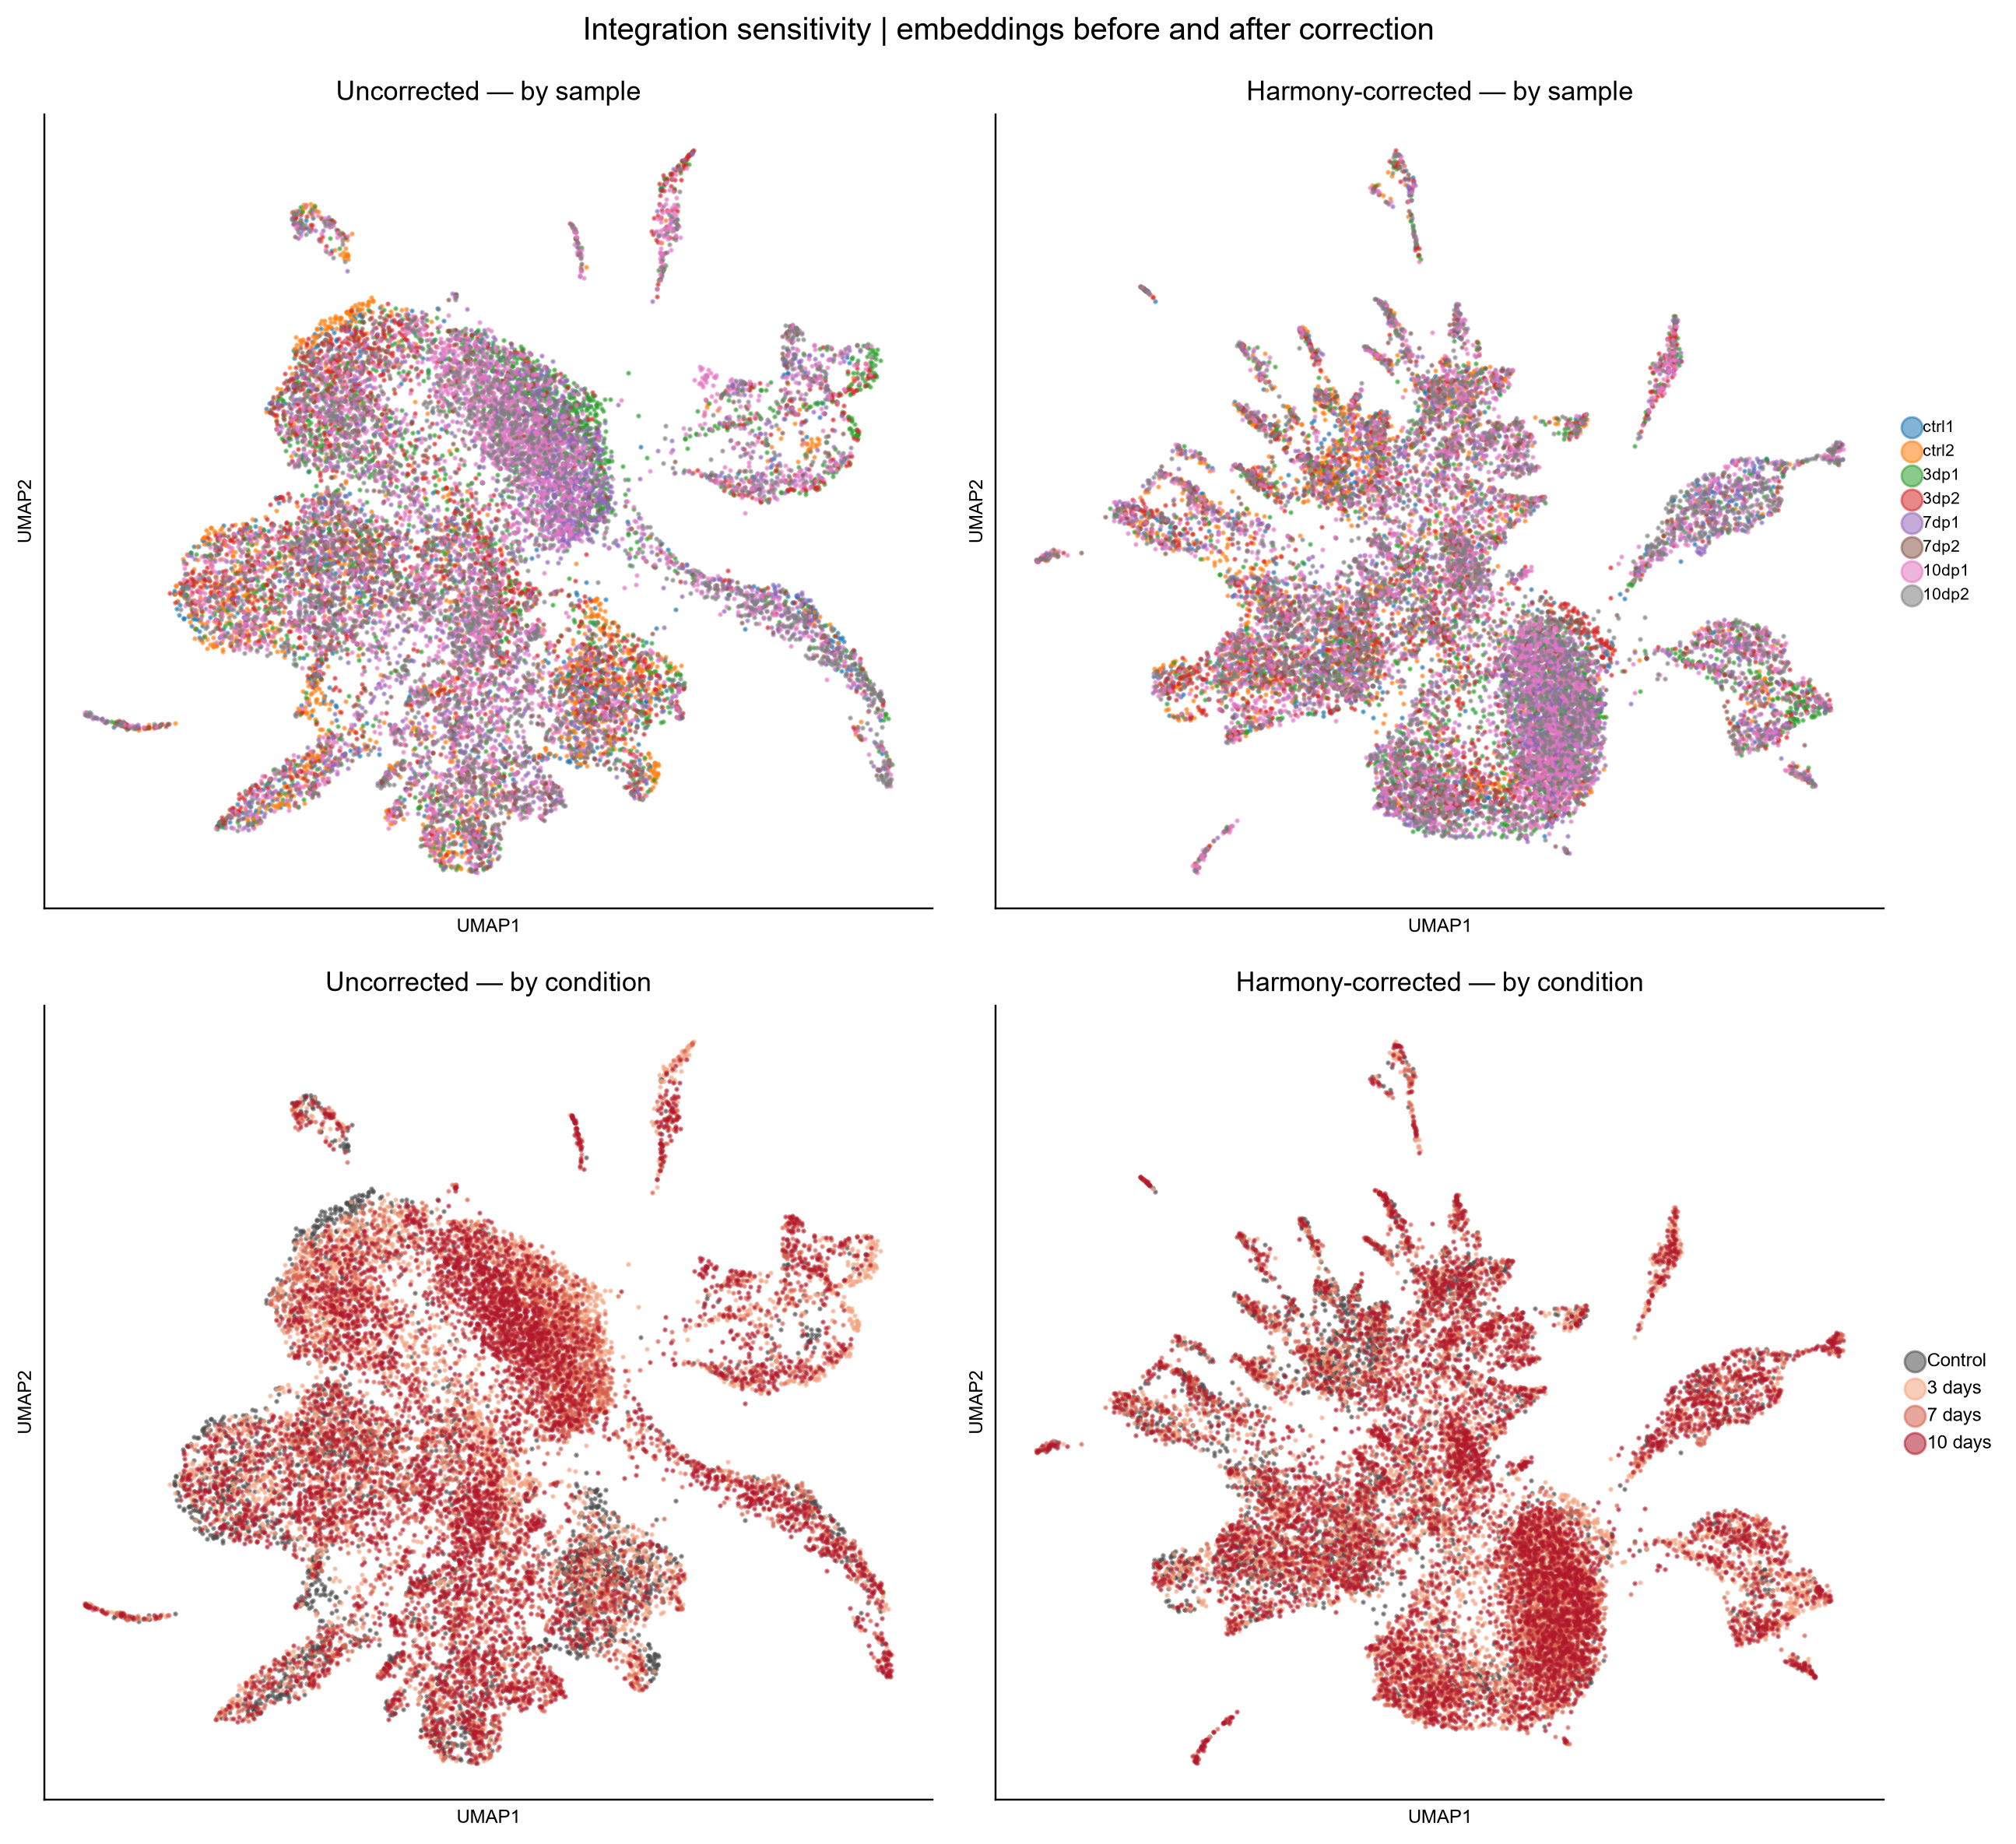

In [12]:
fig = ic.figure_embeddings(adata_int, annotated)

Saved int_fig2_variance_before_after -> figures/integration_check/


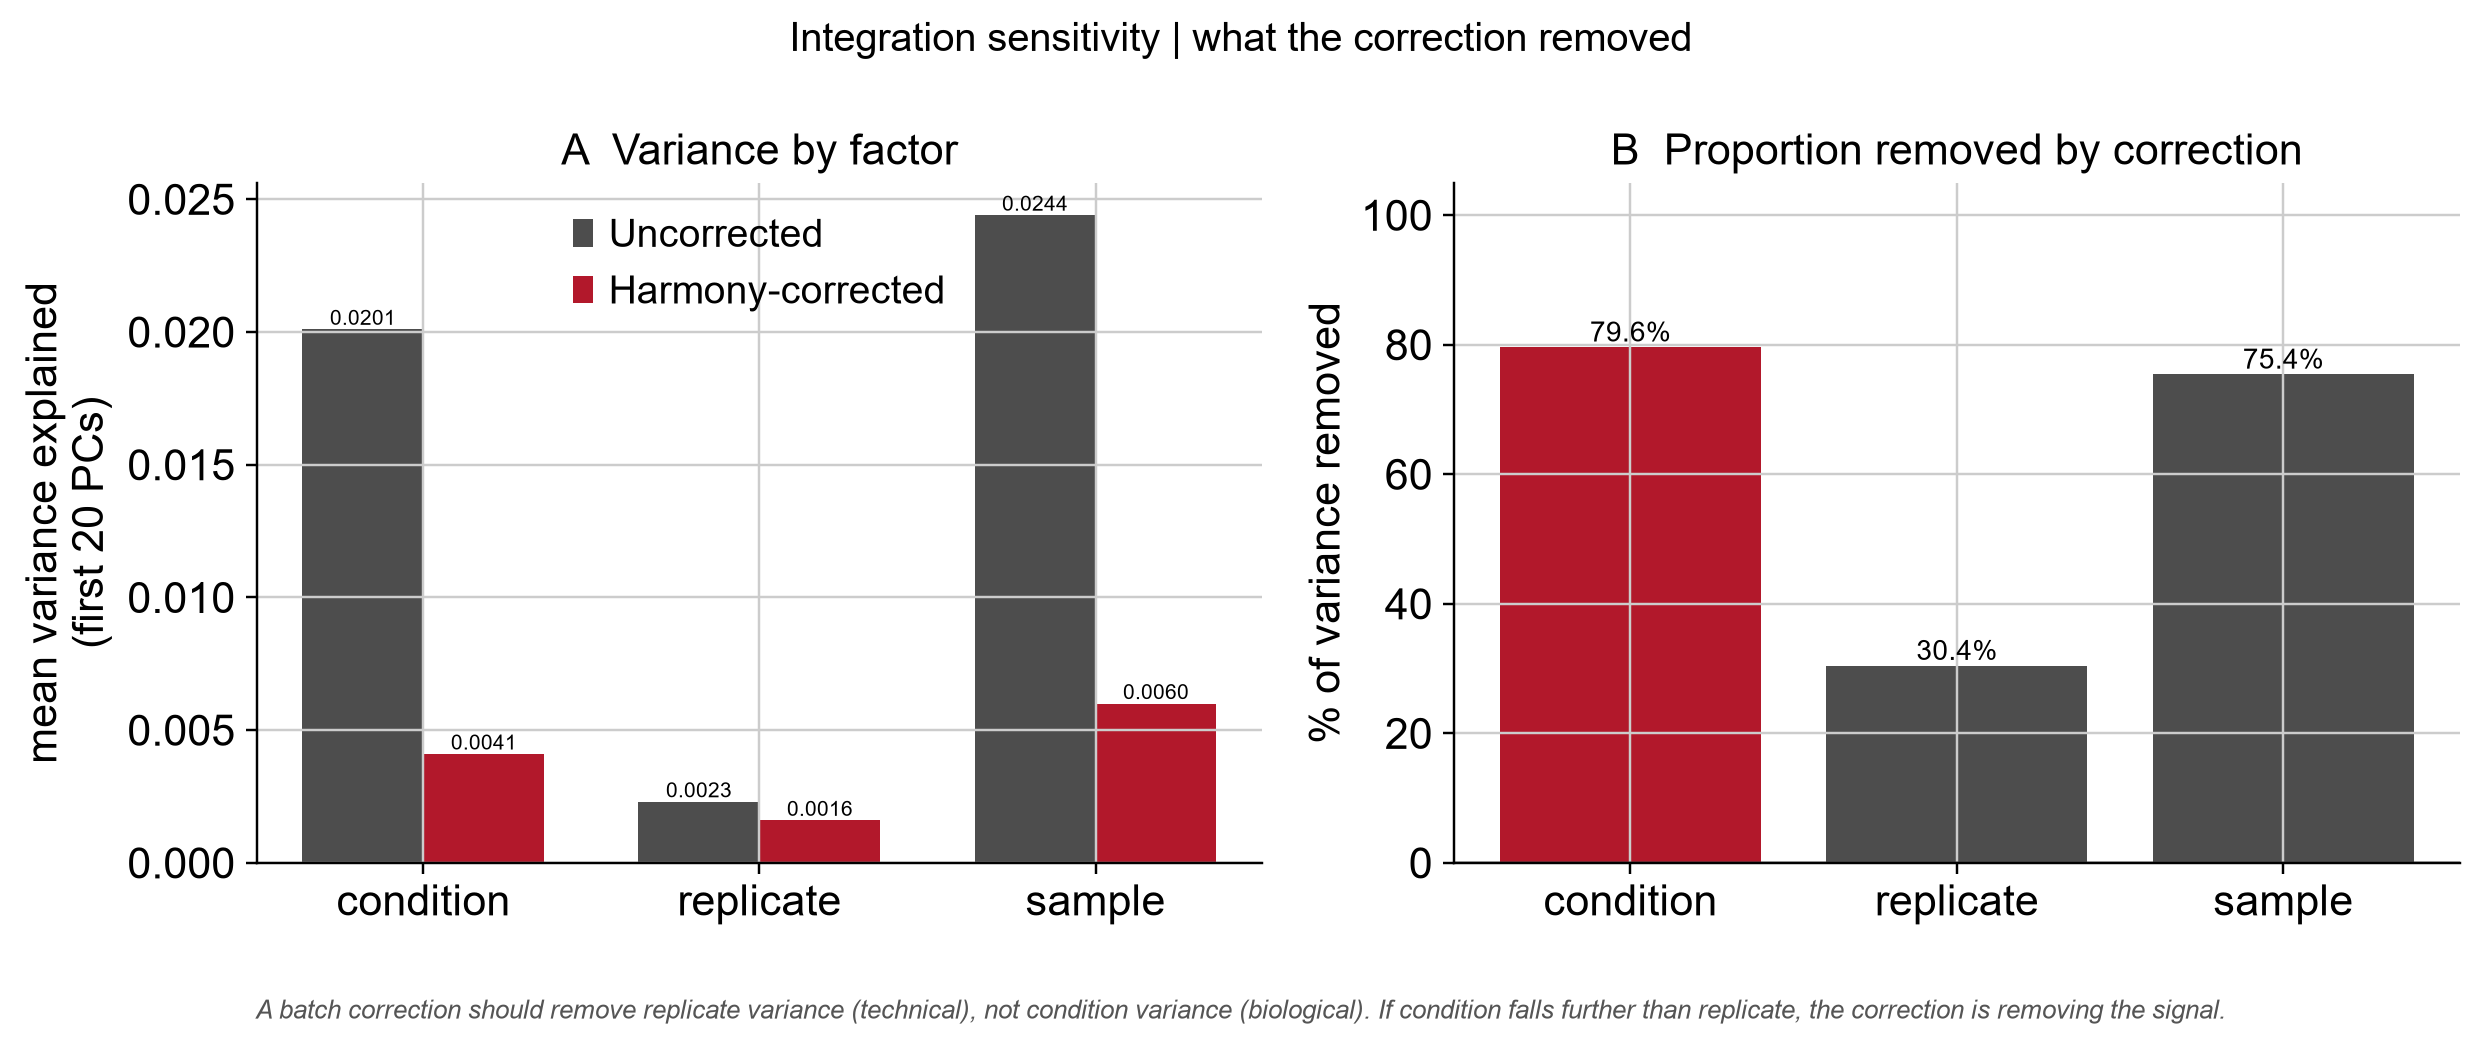

In [13]:
fig = ic.figure_variance(var_df)

Saved int_fig3_cluster_confusion -> figures/integration_check/


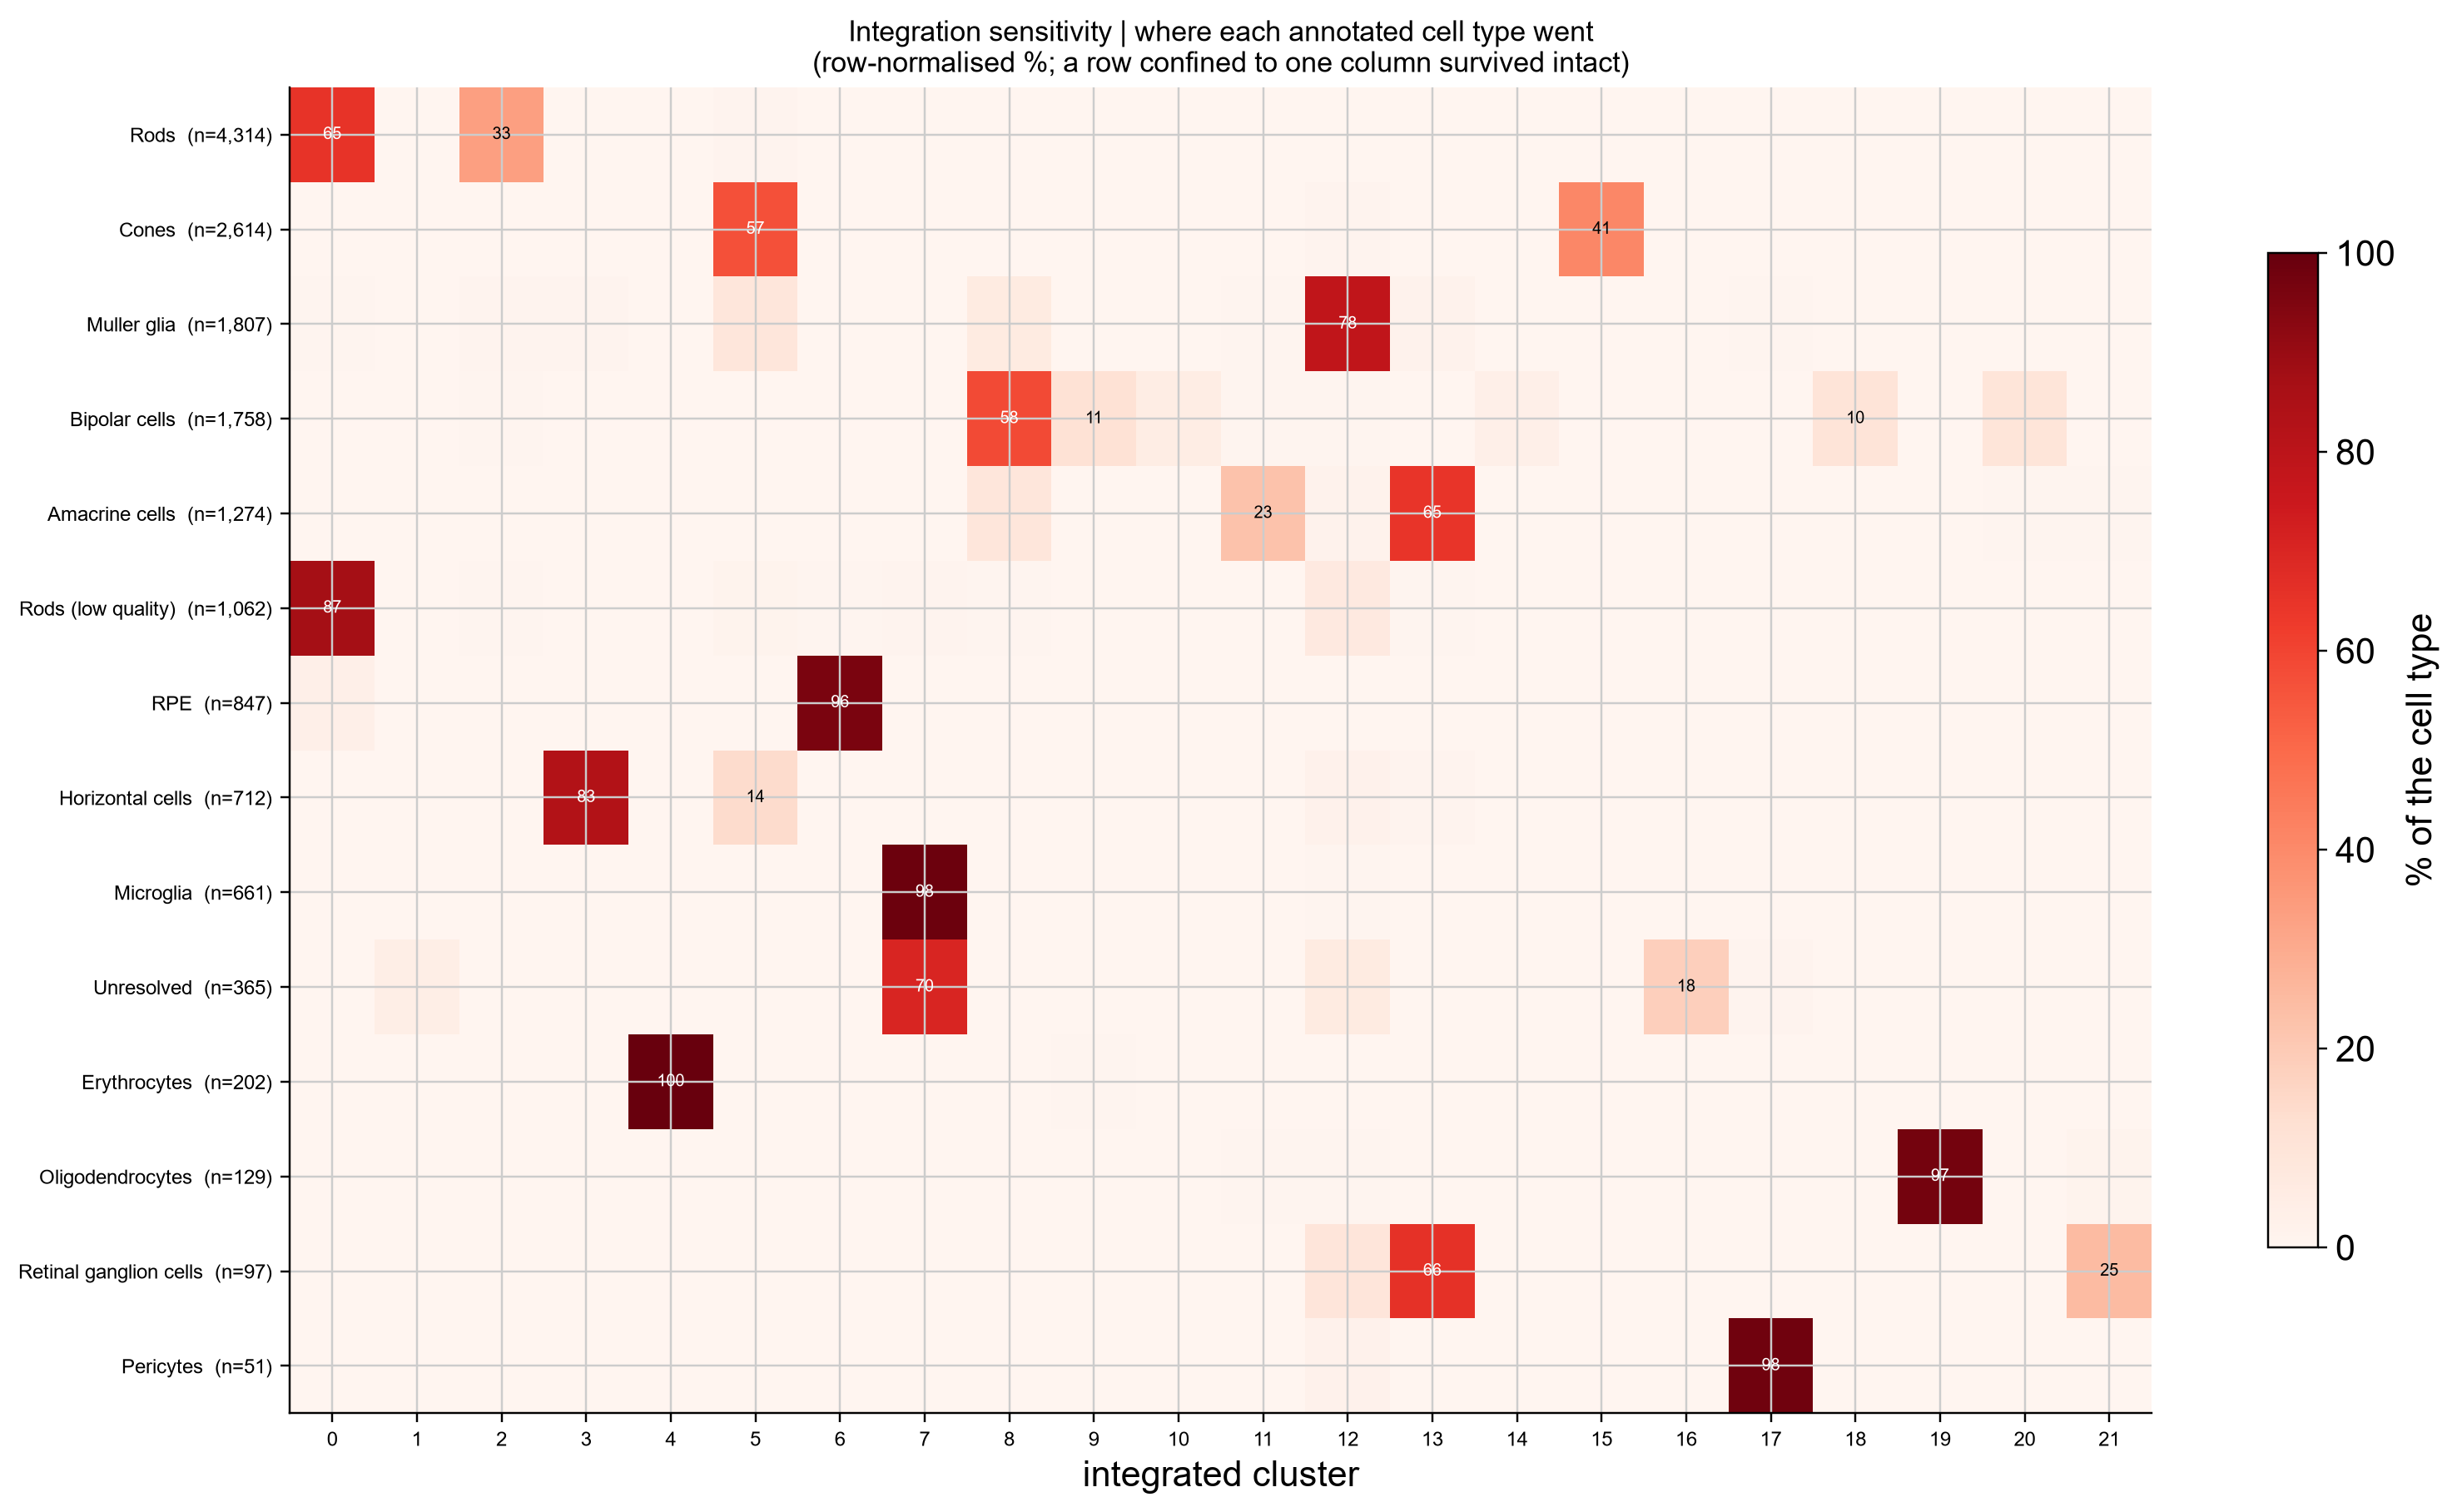

In [14]:
fig = ic.figure_purity(adata_int)

Saved int_fig4_key_results -> figures/integration_check/


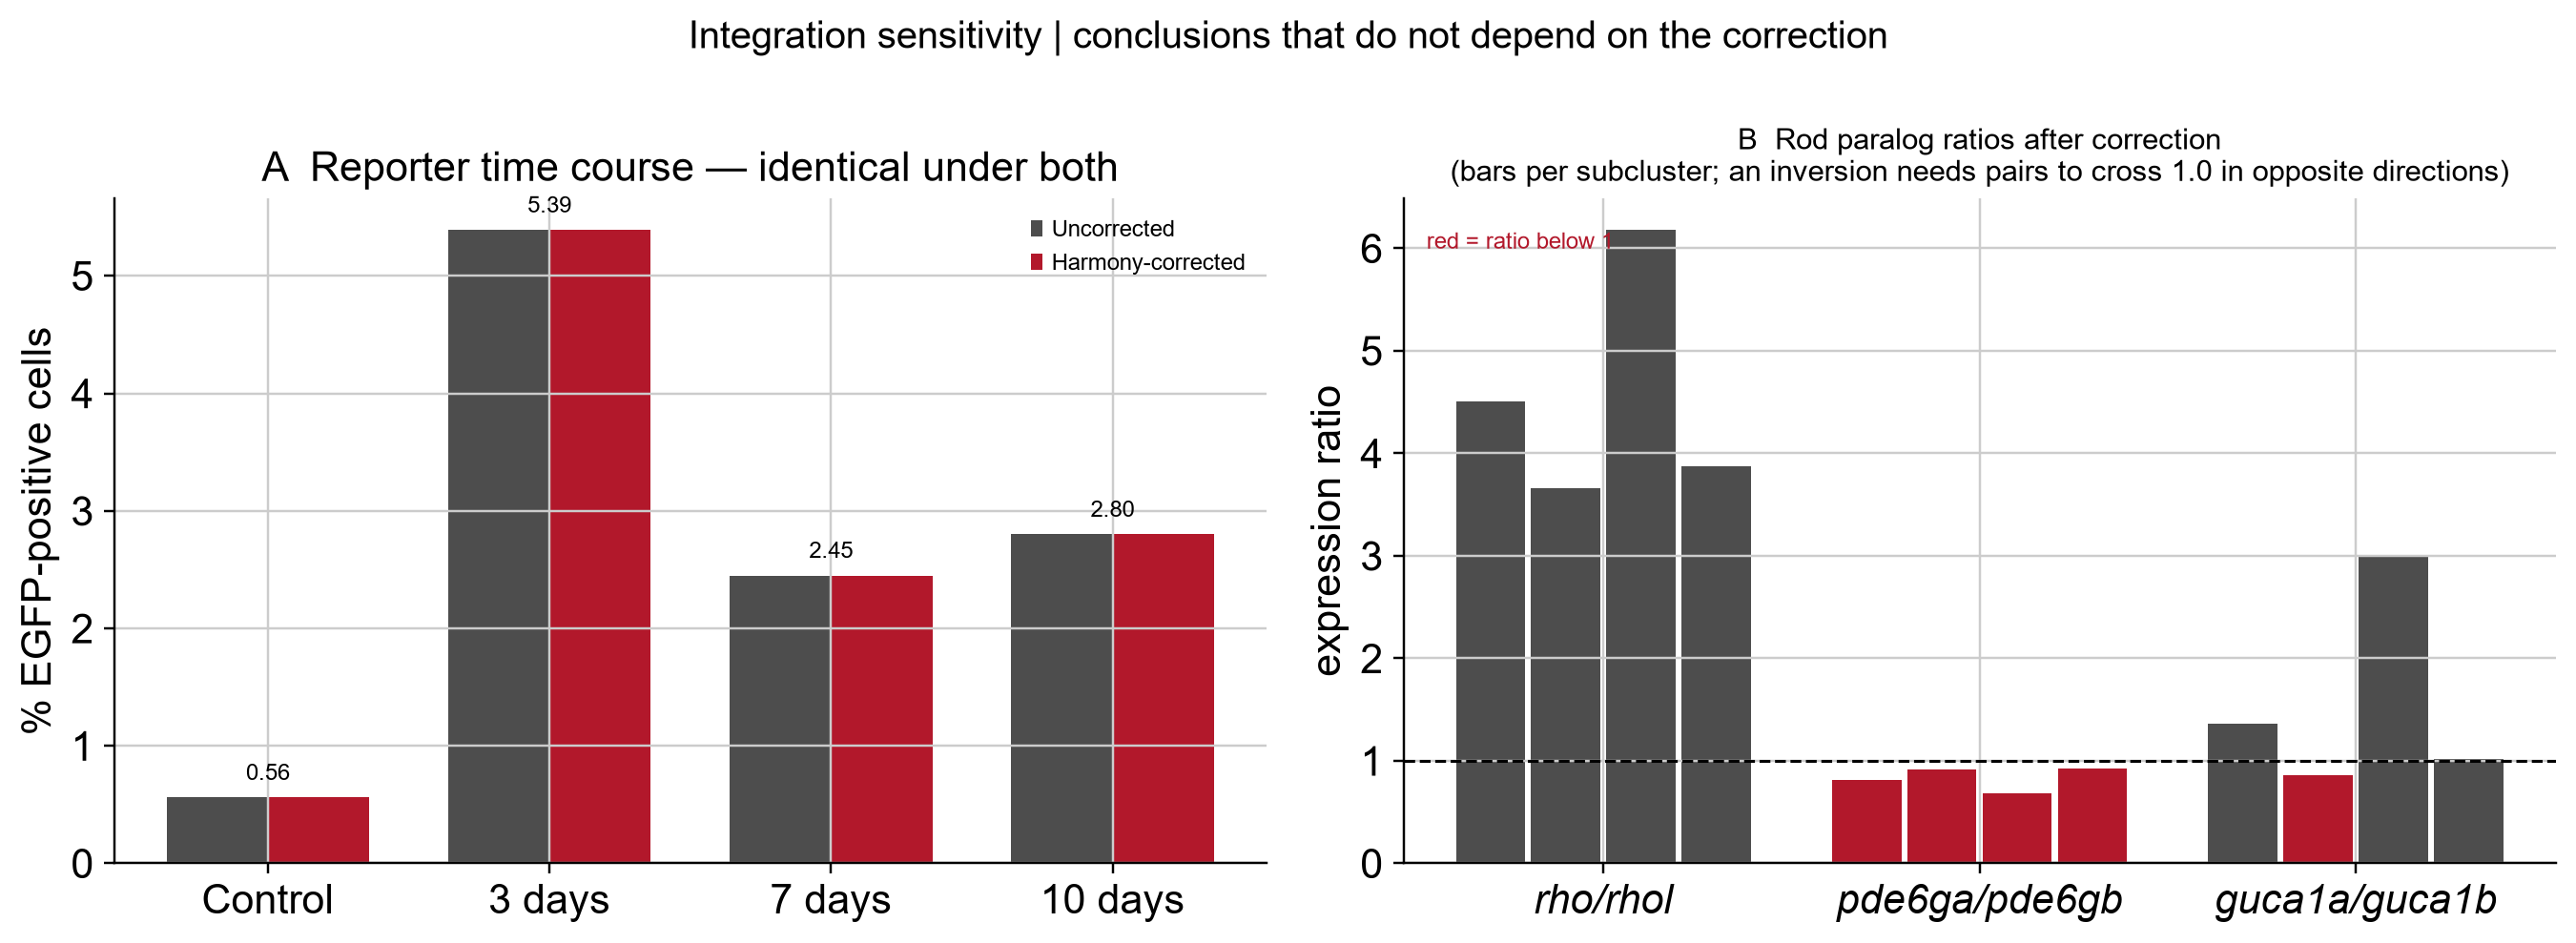

In [15]:
fig = ic.figure_key_comparisons(egfp_df, paralogs)


### Interpretation

**Figure 1 (embeddings).** The top row is what the correction was asked to do —
mix the samples. The bottom row is what it also did. If the conditions separate
visibly on the left and much less on the right, the correction has flattened the
injury signal.

**Figure 2 (variance).** The decisive panel. Replicate variance is purely
technical and is what should be removed; condition variance carries the biology.
If the condition bar in panel B is taller than the replicate bar, the correction
removed signal preferentially.

**Figure 3 (confusion heatmap).** A row confined to one column survived intact; a
row spread across several was dispersed. Check the small populations — retinal
ganglion cells and horizontal cells — since those are where the annotation
findings live.

**Figure 4 (key results).** The two conclusions that must not depend on the
correction. Panel A should show identical bars.


## 9. Summary — what changed and what did not

In [16]:
summary = ic.summarise(agreement, egfp_df, verdict, purity)
ic.save_int_table(summary, "integration_sensitivity_summary.csv")


INTEGRATION SENSITIVITY — SUMMARY
                                             quantity uncorrected  integrated  changed
                                   Number of clusters          20     22.0000     True
               Adjusted Rand index between partitions           —      0.6112     True
Integrated clusters mixing >1 cell type (purity <0.8)           —      3.0000     True
                EGFP time course, max difference (pp)           —      0.0000    False
                   Rod paralog pairs splitting (of 3)           1      1.0000    False

Read this as: which conclusions in the report would change if the batch correction decision had gone the other way. Anything with changed=False is robust to that choice.
Wrote tables\integration_check\integration_sensitivity_summary.csv  (5 rows)


WindowsPath('D:/retina/project1_zebrafish_retina/tables/integration_check/integration_sensitivity_summary.csv')

In [17]:
# Save the corrected object separately; the primary results are never overwritten.
ic._ensure_dirs()
out = ic.INT_RESULTS / "08_integrated.h5ad"
adata_int.write_h5ad(out, compression="gzip")
print(f"Saved {out.relative_to(cfg.REPO_ROOT)} "
      f"({out.stat().st_size / 1e6:.1f} MB)")

Saved results_integrated\08_integrated.h5ad (182.7 MB)



### What to record in the report

Add a short subsection to the Discussion stating:

1. That integration was tested as a sensitivity analysis, not adopted.
2. How much batch variance Harmony removed — and how much **condition** variance
   it removed with it.
3. Whether the EGFP time course moved (it should not).
4. Whether Müller glia remained the reporter-enriched population.
5. Whether the rod paralog verdict changed.

Then update `docs/method_comparison.md` and add harmonypy to `requirements.txt`.

### What to check before continuing

- [ ] harmonypy version recorded in `docs/session_info.json`
- [ ] EGFP time course identical between the two analyses
- [ ] Cluster purity inspected; any cluster below 0.8 explained
- [ ] Rod paralog verdict compared against the uncorrected result
- [ ] `results_integrated/` added to `.gitignore` (it holds a large `.h5ad`)